In [3]:
import sys
import os
from pathlib import Path

import torch

sys.path.append(os.path.abspath("../src"))

from models import SqueezeNet

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

In [4]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [5]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [ ]:
train_loader, val_loader, test_loader = prepare_data(df)

device = get_device()

model = SqueezeNet(num_classes=2, in_channels=1).to(device)

criterion, optimizer = setup_training(model)

Using MPS (GPU)


In [7]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "squeezenet_binary_target")

NameError: name 'model' is not defined

(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

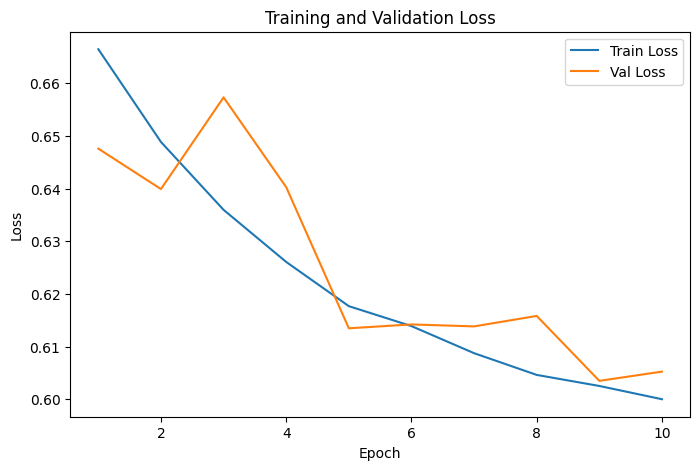

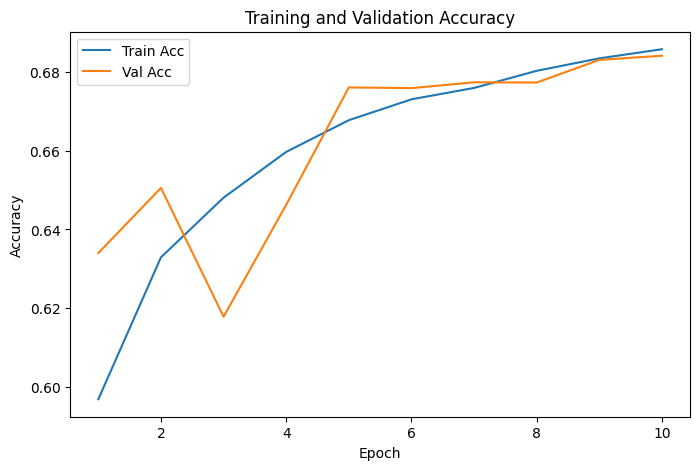

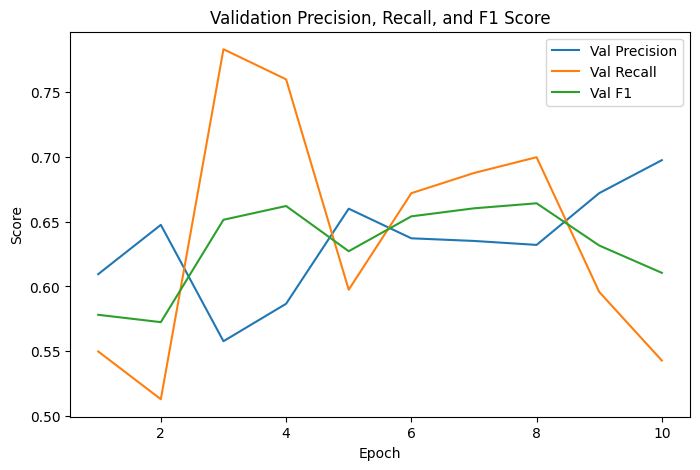

In [ ]:
plot_training_history(history)

In [ ]:
save_path = get_model_path("squeezenet_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = SqueezeNet(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/squeezenet_binary_target.pt


Val: 100%|██████████| 255/255 [04:32<00:00,  1.07s/it, avg_acc=0.6820, avg_loss=0.6073]


Test Results
  Loss: 0.6073
  Accuracy: 0.6820
  Precision: 0.6394
  Recall: 0.7150
  F1 Score: 0.6751


In [ ]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"], "({:.2f}%)".format(result["probabilities"][result["predicted_class"]]*100))
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])

Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_002/images/00001620_003.png
Predicted class: normal (83.72%)
True label: normal
Probabilities: {'normal': 0.837157130241394, 'abnormal': 0.16284286975860596}
